In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load ratings data
ratings = pd.read_csv('../data/u.data', 
                      sep='\t', 
                      names=['user_id', 'movie_id', 'rating', 'timestamp'])

# Load movies data
movies = pd.read_csv('../data/u.item',
                     sep='|',
                     encoding='latin-1',
                     names=['movie_id', 'title', 'release_date', 'video_release', 
                            'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation',
                            'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
                            'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
                            'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'])

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)
print("\nFirst 5 ratings:")
ratings.head()

Ratings shape: (100000, 4)
Movies shape: (1682, 24)

First 5 ratings:


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [2]:
# Basic statistics
print("=== RATINGS INFO ===")
print(f"Total ratings: {len(ratings):,}")
print(f"Total users: {ratings['user_id'].nunique()}")
print(f"Total movies: {ratings['movie_id'].nunique()}")
print(f"Rating scale: {ratings['rating'].min()} to {ratings['rating'].max()}")
print(f"Average rating: {ratings['rating'].mean():.2f}")

print("\n=== MOVIES INFO ===")
print(f"Total movies: {len(movies)}")
print(f"\nFirst 5 movies:")
movies[['movie_id', 'title']].head()

=== RATINGS INFO ===
Total ratings: 100,000
Total users: 943
Total movies: 1682
Rating scale: 1 to 5
Average rating: 3.53

=== MOVIES INFO ===
Total movies: 1682

First 5 movies:


,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


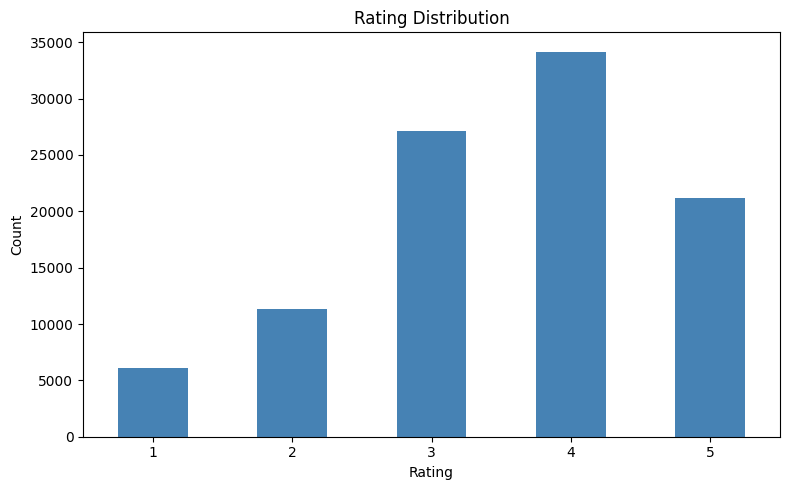


=== TOP 10 MOST RATED MOVIES ===
                        title  num_ratings
             Star Wars (1977)          583
               Contact (1997)          509
                 Fargo (1996)          508
    Return of the Jedi (1983)          507
             Liar Liar (1997)          485
  English Patient, The (1996)          481
                Scream (1996)          478
             Toy Story (1995)          452
         Air Force One (1997)          431
Independence Day (ID4) (1996)          429


In [3]:
# Plot rating distribution
plt.figure(figsize=(8,5))
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Most rated movies
print("\n=== TOP 10 MOST RATED MOVIES ===")
most_rated = ratings.groupby('movie_id').size().reset_index(name='num_ratings')
most_rated = most_rated.merge(movies[['movie_id', 'title']], on='movie_id')
most_rated = most_rated.sort_values('num_ratings', ascending=False).head(10)
print(most_rated[['title', 'num_ratings']].to_string(index=False))

In [4]:
# How many ratings per user?
ratings_per_user = ratings.groupby('user_id').size()
ratings_per_movie = ratings.groupby('movie_id').size()

print("=== RATINGS PER USER ===")
print(f"Average ratings per user: {ratings_per_user.mean():.1f}")
print(f"Most active user: {ratings_per_user.max()} ratings")
print(f"Least active user: {ratings_per_user.min()} ratings")

print("\n=== RATINGS PER MOVIE ===")
print(f"Average ratings per movie: {ratings_per_movie.mean():.1f}")
print(f"Most rated movie: {ratings_per_movie.max()} ratings")
print(f"Least rated movie: {ratings_per_movie.min()} ratings")

# Sparsity of the matrix
sparsity = 1 - (len(ratings) / (ratings['user_id'].nunique() * ratings['movie_id'].nunique()))
print(f"\n=== MATRIX SPARSITY ===")
print(f"Sparsity: {sparsity:.2%}")
print("(how many user-movie combinations have NO rating)")

=== RATINGS PER USER ===
Average ratings per user: 106.0
Most active user: 737 ratings
Least active user: 20 ratings

=== RATINGS PER MOVIE ===
Average ratings per movie: 59.5
Most rated movie: 583 ratings
Least rated movie: 1 ratings

=== MATRIX SPARSITY ===
Sparsity: 93.70%
(how many user-movie combinations have NO rating)
